In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import sqlite3
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

csv_path = "/content/drive/MyDrive/DataAnalytics/lab_features.csv"

df = pd.read_csv(csv_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29156 entries, 0 to 29155
Columns: 190 entries, stay_id to pH_std
dtypes: float64(162), int64(6), object(22)
memory usage: 42.3+ MB


In [ ]:
print(df.columns.to_list())


['stay_id', 'subject_id', 'hadm_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'icu_los_days', 'win_start', 'win_end', 'race_simplified', 'HR_bin0_mean', 'HR_bin1_mean', 'HR_bin2_mean', 'HR_bin3_mean', 'HR_bin4_mean', 'HR_bin5_mean', 'HR_bin6_mean', 'HR_bin7_mean', 'MAP_bin0_mean', 'MAP_bin1_mean', 'MAP_bin2_mean', 'MAP_bin3_mean', 'MAP_bin4_mean', 'MAP_bin5_mean', 'MAP_bin6_mean', 'MAP_bin7_mean', 'RR_bin0_mean', 'RR_bin1_mean', 'RR_bin2_mean', 'RR_bin3_mean', 'RR_bin4_mean', 'RR_bin5_mean', 'RR_bin6_mean', 'RR_bin7_mean', 'SpO2_bin0_mean', 'SpO2_bin1_mean', 'SpO2_bin2_mean', 'SpO2_bin3_mean', 'SpO2_bin4_mean', 'SpO2_bin5_mean', 'SpO2_bin6_mean', 'SpO2_bin7_mean', 'Temp_bin0_mean

In [ ]:
df = df.copy()


df['intime'] = pd.to_datetime(df['intime'], errors='coerce')
df['outtime'] = pd.to_datetime(df['outtime'], errors='coerce')

conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')

query_input = """
SELECT subject_id, itemid, starttime, endtime
FROM inputevents
WHERE itemid IS NOT NULL;
"""
inputevents = pd.read_sql_query(query_input, conn)


inputevents['starttime'] = pd.to_datetime(inputevents['starttime'], errors='coerce')
inputevents['endtime'] = pd.to_datetime(inputevents['endtime'], errors='coerce')


d_items = pd.read_sql_query("""
SELECT itemid, label
FROM d_items
WHERE linksto='inputevents';
""", conn)

conn.close()

inputevents = inputevents.merge(d_items, on='itemid', how='left')

def get_meds(row):
    sid = row['subject_id']
    t_in = row['intime']
    t_out = row['outtime']


    sub = inputevents[inputevents['subject_id'] == sid]


    mask = (
        ((sub['starttime'] >= t_in) & (sub['starttime'] <= t_out)) |
        ((sub['endtime'] >= t_in) & (sub['endtime'] <= t_out))
    )
    overlap = sub[mask]


    return sorted(overlap['label'].dropna().unique())


df['medications_used'] = df.apply(get_meds, axis=1)


print(df[['subject_id', 'intime', 'outtime', 'medications_used']].head())


KeyboardInterrupt: 

In [ ]:
n_null = df['medications_used'].isna().sum()
print(f"⚠️ 투여 약물 기록이 없는 환자 수: {n_null}명 ({100 * n_null / len(df):.2f}%)")


In [ ]:
df_drugs = df[['subject_id', 'medications_used']].explode('medications_used')


unique_drugs = df_drugs['medications_used'].nunique()
print(f"✅ 전체 환자에서 사용된 고유 약물 종류 수: {unique_drugs}가지")


top20_drugs = (
    df_drugs['medications_used']
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'index': 'medication', 'medications_used': 'count'})
)

print("\n💊 사용 빈도 상위 20개 약물:")
print(top20_drugs)


In [ ]:
df_nonnull = df.dropna(subset=['medications_used']).copy()

mlb = MultiLabelBinarizer()
drug_matrix = pd.DataFrame(
    mlb.fit_transform(df_nonnull['medications_used']),
    columns=mlb.classes_,
    index=df_nonnull.index
)

df_binary = pd.concat([df_nonnull[['subject_id', 'los']], drug_matrix], axis=1)

print(f"✅ 약물 변수 수: {len(drug_matrix.columns)}개")
print(f"✅ 데이터 크기: {df_binary.shape}")
df_binary.head()


In [ ]:
drug_stats = (
    df_binary.drop(columns=['subject_id'])
    .melt(id_vars='los', var_name='drug', value_name='used')
    .query('used == 1')
    .groupby('drug')['los']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
)


In [ ]:


scaler = MinMaxScaler()


drug_stats['z_mean'] = scaler.fit_transform(drug_stats[['mean']])
drug_stats['z_std']  = scaler.fit_transform(drug_stats[['std']])

drug_stats['sqrt_count'] = np.sqrt(drug_stats['count'])
drug_stats['z_count'] = 1 - scaler.fit_transform(drug_stats[['sqrt_count']])


alpha, beta, gamma = 0.6, 0.3, 0.1
drug_stats['risk_score'] = (
    alpha * drug_stats['z_mean'] +
    beta * drug_stats['z_std'] +
    gamma * drug_stats['z_count']
)

drug_stats['risk_category'] = pd.qcut(drug_stats['risk_score'], 3, labels=['Low', 'Medium', 'High'])


top20_risky = drug_stats.sort_values('risk_score', ascending=False).head(20)

plt.figure(figsize=(10, 6))
bars = plt.barh(top20_risky.index[::-1], top20_risky['risk_score'][::-1], color='salmon', edgecolor='black')

for i, (score, cat) in enumerate(zip(top20_risky['risk_score'][::-1], top20_risky['risk_category'][::-1])):
    plt.text(score + 0.01, i, cat, va='center', fontsize=9, color='black', fontweight='bold')

plt.title('💊 상위 20개 약물 위험도 (LOS 기반)')
plt.xlabel('Risk Score')
plt.ylabel('Drug Name')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
drug_stats['risk_category'].value_counts(dropna=False)


,count
risk_category,
Low,86
High,86
Medium,84
NaN,20


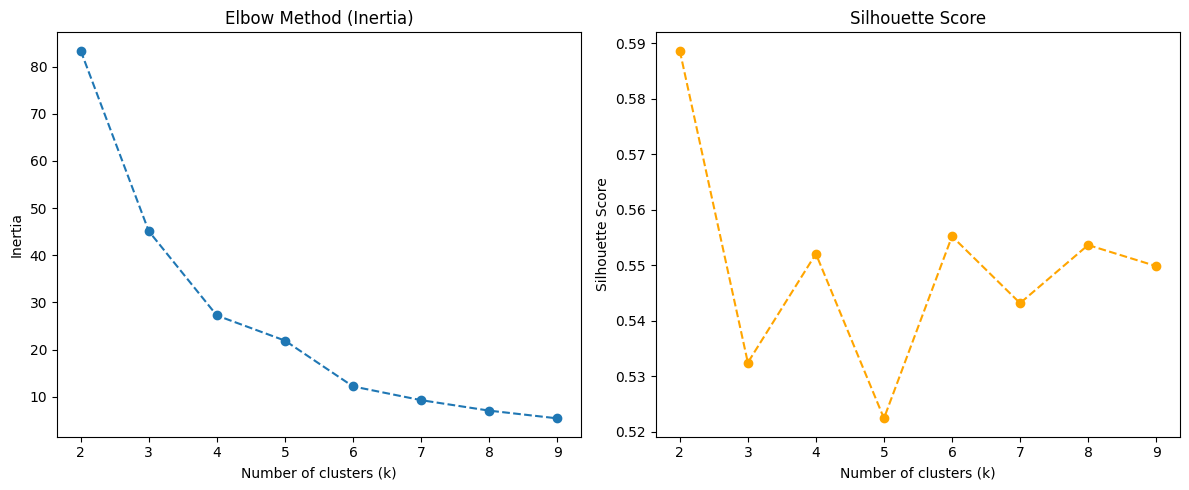

In [ ]:

X = drug_stats[['risk_score']].dropna().copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


K_range = range(2, 10)

inertia_list = []
silhouette_list = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)

    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, kmeans.labels_))


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(K_range, inertia_list, marker='o', linestyle='--')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')


plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_list, marker='o', linestyle='--', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [ ]:

valid_idx = drug_stats['risk_score'].dropna().index

drug_stats.loc[valid_idx, 'cluster'] = cluster_labels

drug_stats['cluster'] = drug_stats['cluster'].fillna(-1)



### **약물 피쳐 생성**

In [ ]:
df = df.copy()

df['intime'] = pd.to_datetime(df['intime'], errors='coerce')
df['outtime'] = pd.to_datetime(df['outtime'], errors='coerce')

conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')

query_input = """
SELECT subject_id, itemid, starttime, endtime
FROM inputevents
WHERE itemid IS NOT NULL;
"""
inputevents = pd.read_sql_query(query_input, conn)
inputevents['starttime'] = pd.to_datetime(inputevents['starttime'], errors='coerce')
inputevents['endtime'] = pd.to_datetime(inputevents['endtime'], errors='coerce')

d_items = pd.read_sql_query("""
SELECT itemid, label
FROM d_items
WHERE linksto='inputevents';
""", conn)
conn.close()

inputevents = inputevents.merge(d_items, on='itemid', how='left')


def get_drugs_in_window(row, hours):
    sid = row['subject_id']
    t_in = row['intime']
    t_end = t_in + pd.Timedelta(hours=hours)


    sub = inputevents[inputevents['subject_id'] == sid]


    mask = (
        ((sub['starttime'] >= t_in) & (sub['starttime'] <= t_end)) |
        ((sub['endtime'] >= t_in) & (sub['endtime'] <= t_end))
    )
    overlap = sub[mask]

    return sorted(overlap['label'].dropna().unique())

def get_drugs_full(row):
    sid = row['subject_id']
    t_in = row['intime']
    t_out = row['outtime']
    sub = inputevents[inputevents['subject_id'] == sid]

    mask = (
        ((sub['starttime'] >= t_in) & (sub['starttime'] <= t_out)) |
        ((sub['endtime'] >= t_in) & (sub['endtime'] <= t_out))
    )
    overlap = sub[mask]
    return sorted(overlap['label'].dropna().unique())


df['medications_used_full'] = df.apply(get_drugs_full, axis=1)
df['medications_used_24h']  = df.apply(lambda r: get_drugs_in_window(r, 24), axis=1)
df['medications_used_48h']  = df.apply(lambda r: get_drugs_in_window(r, 48), axis=1)


print(df[['subject_id','medications_used_full','medications_used_24h','medications_used_48h']].head(10))


   subject_id  \
0    18106347   
1    17195991   
2    16284044   
3    16800952   
4    18780420   
5    10525750   
6    12770182   
7    16084235   
8    12224263   
9    19564586   

                                                                                                                                                                                                                                                                                                                                                                                                                       medications_used_full  \
0                                                   [Albumin 5%, Calcium Gluconate, Cefazolin, Dextrose 5%, Furosemide (Lasix), Glycopyrolate (Robinul), Insulin - Glargine, Insulin - Regular, KCL (Bolus), Ketorolac (Toradol), LR, Metoprolol, Morphine Sulfate, NaCl 0.9%, Neostigmine (Prostigmin), OR Cell Saver Intake, OR Crystalloid Intake, PO Intake, Pantoprazole (Protonix), Pi

In [ ]:
df['num_drugs_48h'] = df['medications_used_48h'].apply(lambda x: len(x) if isinstance(x, list) else 0)


In [ ]:
def count_events_48h(row):
    sid = row['subject_id']
    t_in = row['intime']
    t_end = t_in + pd.Timedelta(hours=48)

    sub = inputevents[inputevents['subject_id'] == sid]

    mask = (
        ((sub['starttime'] >= t_in) & (sub['starttime'] <= t_end)) |
        ((sub['endtime'] >= t_in) & (sub['endtime'] <= t_end))
    )

    return sub[mask].shape[0]

df['dose_change_count_48h'] = df.apply(count_events_48h, axis=1)


In [ ]:
df.to_csv('/content/drive/MyDrive/DataAnalytics/icu_features_with_drugs.csv', index=False)
print("✅ df를 CSV 파일로 저장했습니다.")


✅ df를 CSV 파일로 저장했습니다.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DataAnalytics/icu_features_with_drugs.csv')
print("📂 CSV 로드 완료!")
df.head()


📂 CSV 로드 완료!


,stay_id,subject_id,hadm_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,Temp_CV,Pain_CV,HR_CV_scaled,MAP_CV_scaled,RR_CV_scaled,SpO2_CV_scaled,Temp_CV_scaled,VitalStability,dose_stability,StabilizationIndex
0,30588857,18106347,24305596,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2110-01-11 10:16:06,2110-01-12 17:17:47,1.292836,2110-01-11 10:14:00,2110-01-15 17:31:00,...,NaN,0.415432,0.147298,0.094715,0.435534,0.112469,NaN,0.129883,0.514863,0.322373
1,38319097,17195991,23542772,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2110-01-12 00:54:00,2110-01-14 22:07:39,2.884479,2110-01-11 22:47:00,2110-01-18 10:25:00,...,0.002812,1.154699,0.227779,NaN,0.325188,0.123062,0.038681,0.175420,0.524592,0.350006
2,36817845,16284044,23864737,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2110-01-13 09:09:40,2110-01-15 21:45:33,2.524919,2110-01-11 19:58:00,2110-01-17 16:00:00,...,0.004354,0.482205,0.145533,0.217642,0.290827,0.172140,0.059904,0.172140,0.540557,0.356349
3,31337458,16800952,22641185,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2110-01-16 04:28:00,2110-01-17 17:51:08,1.557731,2110-01-16 04:04:00,2110-02-04 17:50:00,...,0.013328,0.125951,0.240794,0.279327,0.481683,0.145456,0.183360,0.240794,0.597357,0.419075
4,32140208,18780420,28977824,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2110-01-17 00:28:00,2110-01-18 01:21:22,1.037060,2110-01-16 23:37:00,2110-01-22 16:07:00,...,0.001019,0.935414,0.199951,NaN,0.388174,0.105643,0.014024,0.152797,0.802547,0.477672


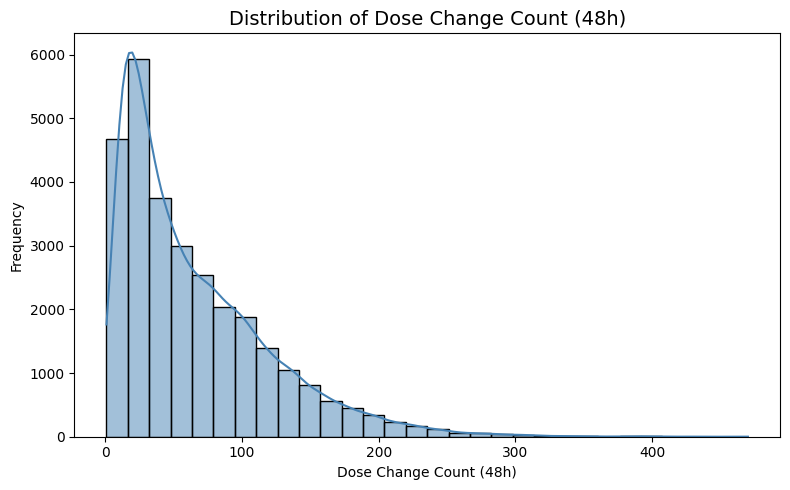

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['dose_change_count_48h'], bins=30, kde=True, color='steelblue')
plt.title("Distribution of Dose Change Count (48h)", fontsize=14)
plt.xlabel("Dose Change Count (48h)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [ ]:
df['intime'] = pd.to_datetime(df['intime'], errors='coerce')
df['outtime'] = pd.to_datetime(df['outtime'], errors='coerce')


df['stay_hours'] = (df['outtime'] - df['intime']).dt.total_seconds() / 3600

def calc_dose_change_rate(row):
    count = row['dose_change_count_48h']
    stay_h = row['stay_hours']

    if pd.isna(stay_h) or stay_h <= 0:
        return np.nan


    if stay_h < 48:
        return count / stay_h


    else:
        return count / 48

df['dose_change_rate'] = df.apply(calc_dose_change_rate, axis=1)


In [ ]:
scaler = MinMaxScaler()
df['dose_change_rate_scaled'] = scaler.fit_transform(df[['dose_change_rate']])
df['dose_change_rate_sqrt'] = np.sqrt(df['dose_change_rate_scaled'])


### **Square-root transform 하기**

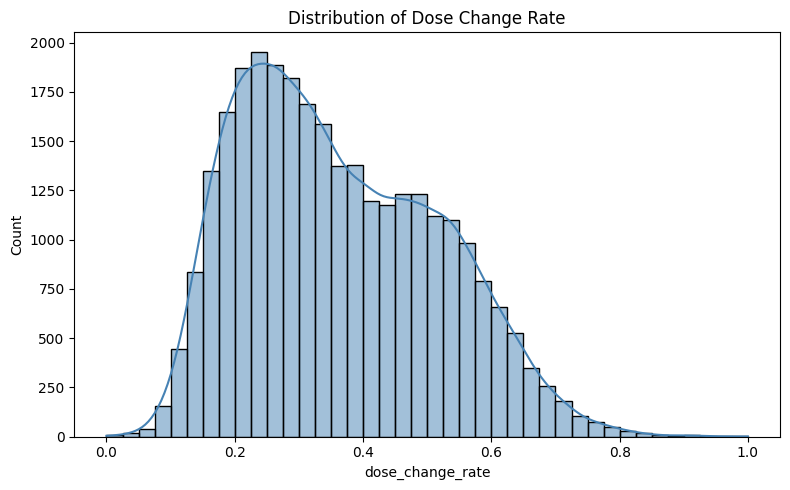

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['dose_change_rate_sqrt'], bins=40, kde=True, color='steelblue')
plt.title("Distribution of Dose Change Rate")
plt.xlabel("dose_change_rate")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


🔍 찾은 vital mean-std pair:
('HR', 'HR_mean', 'HR_std')
('MAP', 'MAP_mean', 'MAP_std')
('RR', 'RR_mean', 'RR_std')
('SpO2', 'SpO2_mean', 'SpO2_std')
('Temp', 'Temp_mean', 'Temp_std')
('Pain', 'Pain_mean', 'Pain_std')
✅ Vital CV 계산 완료!
📌 CV 컬럼: ['HR_CV', 'MAP_CV', 'RR_CV', 'SpO2_CV', 'Temp_CV', 'Pain_CV']


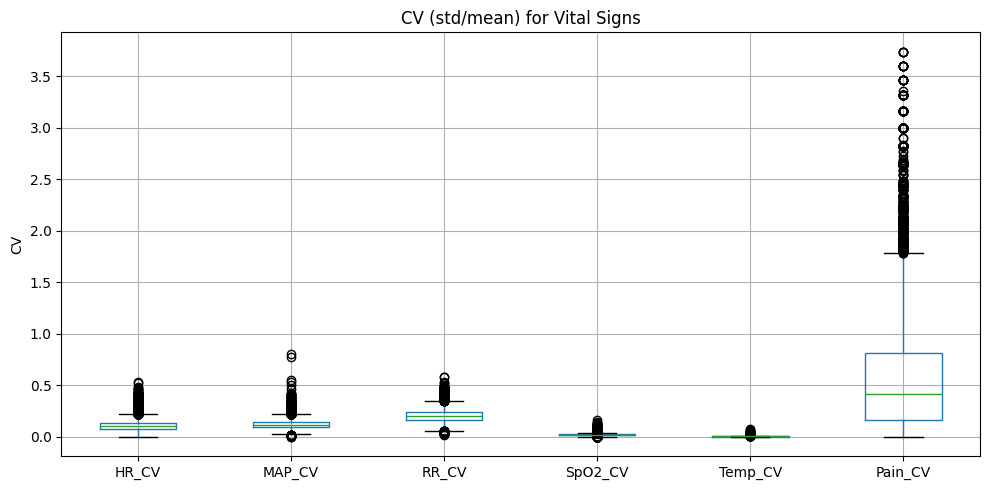

In [ ]:
vital_prefixes = ["HR", "MAP", "RR", "SpO2", "Temp", "Pain"]


vital_pairs = []
for prefix in vital_prefixes:
    mean_col = prefix + "_mean"
    std_col = prefix + "_std"
    if mean_col in df.columns and std_col in df.columns:
        vital_pairs.append((prefix, mean_col, std_col))

print("🔍 찾은 vital mean-std pair:")
for p in vital_pairs:
    print(p)


for prefix, mean_col, std_col in vital_pairs:
    cv_col = prefix + "_CV"
    df[cv_col] = df[std_col] / (df[mean_col] + 1e-6)

print("✅ Vital CV 계산 완료!")


vital_cv_cols = [p[0] + "_CV" for p in vital_pairs]
print("📌 CV 컬럼:", vital_cv_cols)


plt.figure(figsize=(10, 5))
df[vital_cv_cols].boxplot()
plt.title("CV (std/mean) for Vital Signs")
plt.ylabel("CV")
plt.tight_layout()
plt.show()


In [ ]:
vital_cv_cols = ["HR_CV", "MAP_CV", "RR_CV", "SpO2_CV", "Temp_CV"]
scaler = MinMaxScaler()
df[[col + "_scaled" for col in vital_cv_cols]] = scaler.fit_transform(df[vital_cv_cols])


In [ ]:
df["VitalStability"] = df[[col + "_scaled" for col in vital_cv_cols]].median(axis=1)


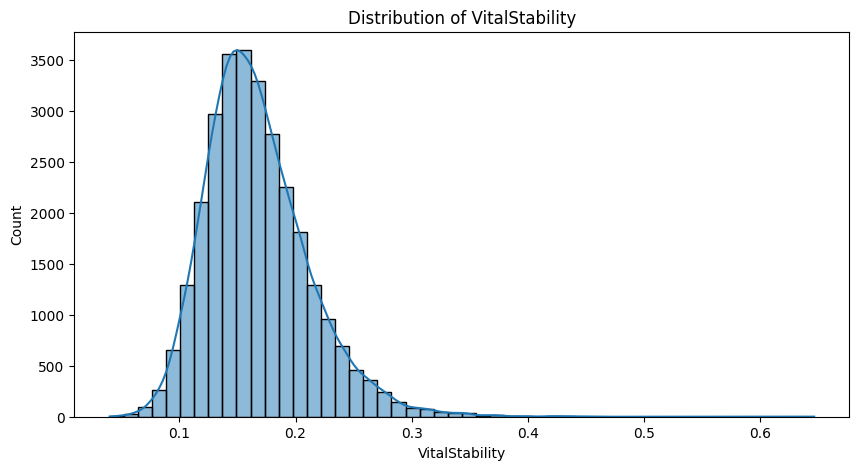

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["VitalStability"], bins=50, kde=True)
plt.title("Distribution of VitalStability")
plt.xlabel("VitalStability")
plt.ylabel("Count")
plt.show()


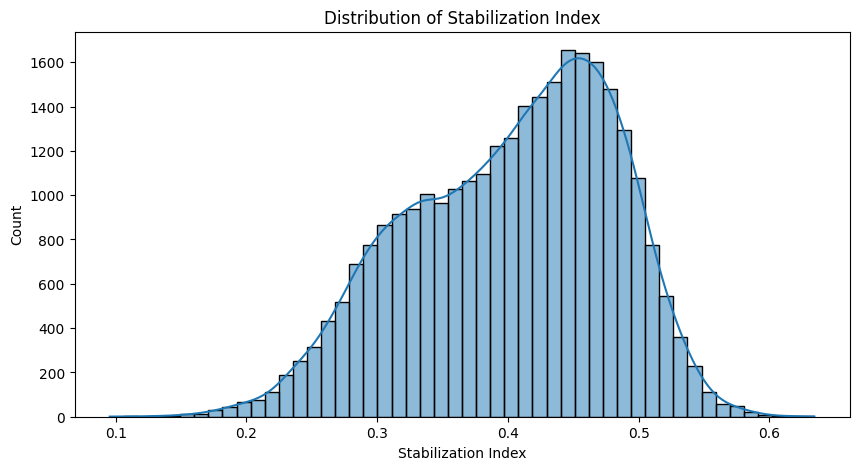

,StabilizationIndex
count,29156.000000
mean,0.402720
std,0.078642
min,0.095497
25%,0.343776
50%,0.413287
75%,0.464215
max,0.634330


In [ ]:
alpha = 0.5
beta = 0.5


df["dose_stability"] = 1 - df["dose_change_rate_sqrt"]

df["StabilizationIndex"] = (
    alpha * df["dose_stability"] +
    beta * df["VitalStability"]
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df["StabilizationIndex"], bins=50, kde=True)
plt.title("Distribution of Stabilization Index")
plt.xlabel("Stabilization Index")
plt.show()

df["StabilizationIndex"].describe()


In [ ]:
df.head()


,stay_id,subject_id,hadm_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,Temp_CV,Pain_CV,HR_CV_scaled,MAP_CV_scaled,RR_CV_scaled,SpO2_CV_scaled,Temp_CV_scaled,VitalStability,dose_stability,StabilizationIndex
0,30588857,18106347,24305596,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2110-01-11 10:16:06,2110-01-12 17:17:47,1.292836,2110-01-11 10:14:00,2110-01-15 17:31:00,...,NaN,0.415432,0.147298,0.094715,0.435534,0.112469,NaN,0.129883,0.514863,0.322373
1,38319097,17195991,23542772,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2110-01-12 00:54:00,2110-01-14 22:07:39,2.884479,2110-01-11 22:47:00,2110-01-18 10:25:00,...,0.002812,1.154699,0.227779,NaN,0.325188,0.123062,0.038681,0.175420,0.524592,0.350006
2,36817845,16284044,23864737,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2110-01-13 09:09:40,2110-01-15 21:45:33,2.524919,2110-01-11 19:58:00,2110-01-17 16:00:00,...,0.004354,0.482205,0.145533,0.217642,0.290827,0.172140,0.059904,0.172140,0.540557,0.356349
3,31337458,16800952,22641185,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2110-01-16 04:28:00,2110-01-17 17:51:08,1.557731,2110-01-16 04:04:00,2110-02-04 17:50:00,...,0.013328,0.125951,0.240794,0.279327,0.481683,0.145456,0.183360,0.240794,0.597357,0.419075
4,32140208,18780420,28977824,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2110-01-17 00:28:00,2110-01-18 01:21:22,1.037060,2110-01-16 23:37:00,2110-01-22 16:07:00,...,0.001019,0.935414,0.199951,NaN,0.388174,0.105643,0.014024,0.152797,0.802547,0.477672


In [ ]:
df.to_csv('/content/drive/MyDrive/DataAnalytics/icu_features_with_drugs.csv', index=False)
print("✅ df를 CSV 파일로 저장했습니다.")


✅ df를 CSV 파일로 저장했습니다.


In [ ]:
df.head()

,stay_id,subject_id,hadm_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,Temp_CV,Pain_CV,HR_CV_scaled,MAP_CV_scaled,RR_CV_scaled,SpO2_CV_scaled,Temp_CV_scaled,VitalStability,dose_stability,StabilizationIndex
0,30588857,18106347,24305596,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2110-01-11 10:16:06,2110-01-12 17:17:47,1.292836,2110-01-11 10:14:00,2110-01-15 17:31:00,...,NaN,0.415432,0.147298,0.094715,0.435534,0.112469,NaN,0.129883,0.514863,0.322373
1,38319097,17195991,23542772,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2110-01-12 00:54:00,2110-01-14 22:07:39,2.884479,2110-01-11 22:47:00,2110-01-18 10:25:00,...,0.002812,1.154699,0.227779,NaN,0.325188,0.123062,0.038681,0.175420,0.524592,0.350006
2,36817845,16284044,23864737,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2110-01-13 09:09:40,2110-01-15 21:45:33,2.524919,2110-01-11 19:58:00,2110-01-17 16:00:00,...,0.004354,0.482205,0.145533,0.217642,0.290827,0.172140,0.059904,0.172140,0.540557,0.356349
3,31337458,16800952,22641185,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2110-01-16 04:28:00,2110-01-17 17:51:08,1.557731,2110-01-16 04:04:00,2110-02-04 17:50:00,...,0.013328,0.125951,0.240794,0.279327,0.481683,0.145456,0.183360,0.240794,0.597357,0.419075
4,32140208,18780420,28977824,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2110-01-17 00:28:00,2110-01-18 01:21:22,1.037060,2110-01-16 23:37:00,2110-01-22 16:07:00,...,0.001019,0.935414,0.199951,NaN,0.388174,0.105643,0.014024,0.152797,0.802547,0.477672
